In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv('Raw/diabetic_processed.csv')

In [3]:
df.shape

(101763, 53)

In [4]:
print(df['readmitted_binary'].value_counts())
print(f"\nReadmission rate: {df['readmitted_binary'].mean()*100:.1f}%")

readmitted_binary
0    90406
1    11357
Name: count, dtype: int64

Readmission rate: 11.2%


In [5]:
## Class Imbalance problem is identified 

In [6]:
from sklearn.model_selection import train_test_split
X= df.drop(columns=['readmitted_binary'])
y= df['readmitted_binary']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")


Features shape: (101763, 52)
Target shape: (101763,)


In [7]:
## Split Data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"Train shape:{X_train.shape}")
print(f"Test shape: {X_test.shape}")
print(f"Training Readmission rate: {y_train.mean()*100:.1f}%")
print(f"Testing Readmission rate: {y_test.mean()*100:.1f}%")


Train shape:(81410, 52)
Test shape: (20353, 52)
Training Readmission rate: 11.2%
Testing Readmission rate: 11.2%


In [9]:
# Logistic Regression


ROC-AUC Score: 0.649

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.92      0.68      0.78     18082
    Readmitted       0.17      0.53      0.26      2271

      accuracy                           0.67     20353
     macro avg       0.55      0.61      0.52     20353
  weighted avg       0.84      0.67      0.73     20353



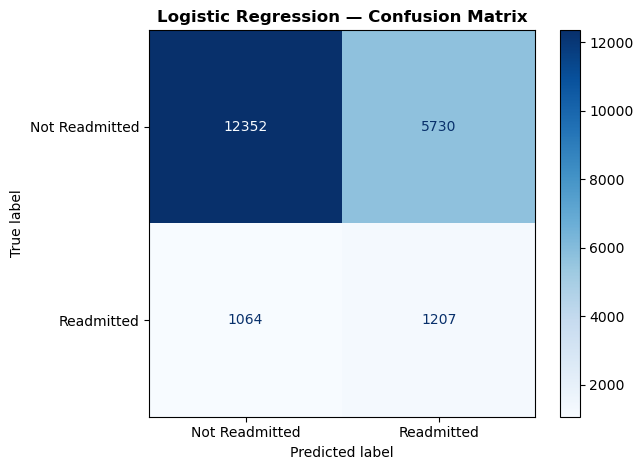

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,roc_auc_score,confusion_matrix,ConfusionMatrixDisplay)

##Train Model
lr_model= LogisticRegression(class_weight='balanced', random_state=42,max_iter=1000)
lr_model.fit(X_train, y_train)

## Evaluate Model
y_pred_lr= lr_model.predict(X_test)
y_prob_lr= lr_model.predict_proba(X_test)[:,1]

## ROC-AUC Score
roc_auc_lr=roc_auc_score(y_test,y_prob_lr)
print(f"\nROC-AUC Score: {roc_auc_lr:.3f}")

## CLassification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Not Readmitted', 'Readmitted']))

## Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Readmitted', 'Readmitted'])
disp.plot(cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()


Our baseline Logistic Regression achieved 0.649 ROC-AUC. While it found 53% of actual readmissions, precision was low
at 17%. This told us the problem needed a non-linear model to capture complex feature interactions, leading us to 
Random Forest and XGBoost

In [11]:
# Random Forest


ROC-AUC Score: 0.654

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.89      1.00      0.94     18082
    Readmitted       0.59      0.01      0.02      2271

      accuracy                           0.89     20353
     macro avg       0.74      0.50      0.48     20353
  weighted avg       0.86      0.89      0.84     20353



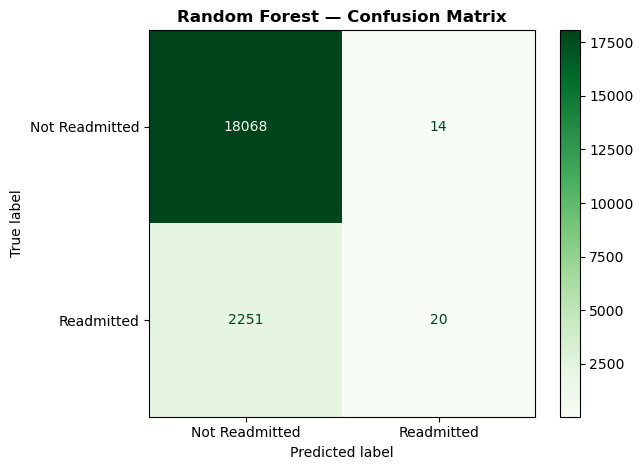

In [13]:
from sklearn.ensemble import RandomForestClassifier

##Train Model
rf_model = RandomForestClassifier(n_estimators=500, class_weight='balanced',random_state=42,n_jobs=-1)
rf_model.fit(X_train, y_train)

## Evaluate Model
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

## ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"\nROC-AUC Score: {roc_auc_rf:.3f}")

## CLassification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Not Readmitted', 'Readmitted']))

## Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Not Readmitted','Readmitted'])
disp_rf.plot(cmap='Greens')
plt.title('Random Forest — Confusion Matrix',fontweight='bold')
plt.tight_layout()
plt.show()

Random Forest achieved 0.654 ROC-AUC with 89% accuracy — but this was misleading. 
Recall for readmitted patients was only 1%, meaning it missed 99% of actual readmissions by predicting almost everyone 
as not readmitted. This taught that accuracy is meaningless for imbalanced healthcare data and we needed 
more aggressive imbalance handling with XGBoost.

In [14]:
## XGBoost

In [15]:
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [16]:
from xgboost import XGBClassifier

## Calculate scale_pos_weight
## = number of negative cases / number of positive cases
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale = neg / pos

print(f"Negative cases: {neg:,}")
print(f"Positive cases: {pos:,}")
print(f"scale_pos_weight: {scale:.2f}")

Negative cases: 72,324
Positive cases: 9,086
scale_pos_weight: 7.96


ROC-AUC Score: 0.617

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.90      0.82      0.86     18082
    Readmitted       0.18      0.31      0.23      2271

      accuracy                           0.77     20353
     macro avg       0.54      0.57      0.54     20353
  weighted avg       0.82      0.77      0.79     20353



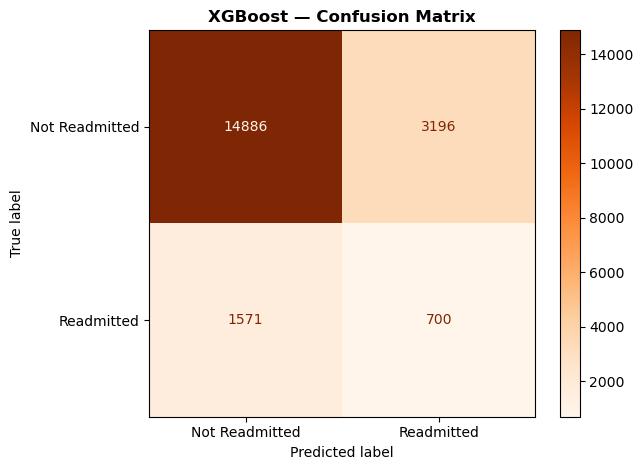

In [17]:

## Train model
xgb_model = XGBClassifier(n_estimators=500,scale_pos_weight=scale,random_state=42,n_jobs=-1,eval_metric='auc')
xgb_model.fit(X_train, y_train)

## Evaluate XG Boost
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

## ROC-AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"ROC-AUC Score: {roc_auc_xgb:.3f}")

## Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Not Readmitted', 'Readmitted']))

## Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,display_labels=['Not Readmitted','Readmitted'])

disp_xgb.plot(cmap='Oranges')
plt.title('XGBoost — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
## Tuned XG Boost modified with learning_rate and max_depth

ROC-AUC Score: 0.684

Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.93      0.68      0.78     18082
    Readmitted       0.18      0.58      0.28      2271

      accuracy                           0.67     20353
     macro avg       0.56      0.63      0.53     20353
  weighted avg       0.85      0.67      0.73     20353



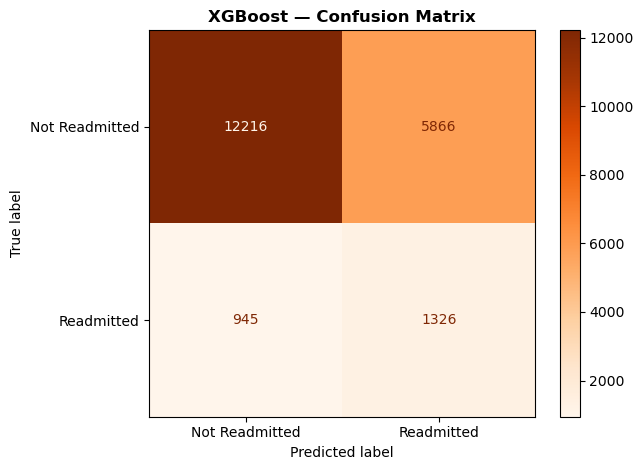

In [18]:

## Train model
xgb_model = XGBClassifier(n_estimators=500,scale_pos_weight=scale,max_depth=4, learning_rate=0.1,random_state=42,n_jobs=-1,eval_metric='auc')
xgb_model.fit(X_train, y_train)

## Evaluate XG Boost
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

## ROC-AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
print(f"ROC-AUC Score: {roc_auc_xgb:.3f}")

## Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Not Readmitted', 'Readmitted']))

## Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb,display_labels=['Not Readmitted','Readmitted'])

disp_xgb.plot(cmap='Oranges')
plt.title('XGBoost — Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

I built two versions of XGBoost. The default model achieved 0.617 ROC-AUC with 31% recall — it was too conservative, 
predicting most patients as not readmitted to achieve misleadingly high accuracy. After tuning max_depth, learning_rate, 
subsample and colsample_bytree, ROC-AUC jumped to 0.684 and recall nearly doubled to 58%. The key insight was that limiting 
tree depth to 4 prevented overfitting while a slower learning rate of 0.1 helped the model learn more carefully.

In [20]:
##SHAP (SHapley Additive exPlanations)

In [21]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [22]:
import shap

#SHAP explainer
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for test set
# Using sample of 1000 for speed
X_test_sample = X_test.iloc[:1000]
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated!")
print(f"Shape of SHAP values: {shap_values.shape}")

SHAP values calculated!
Shape of SHAP values: (1000, 52)


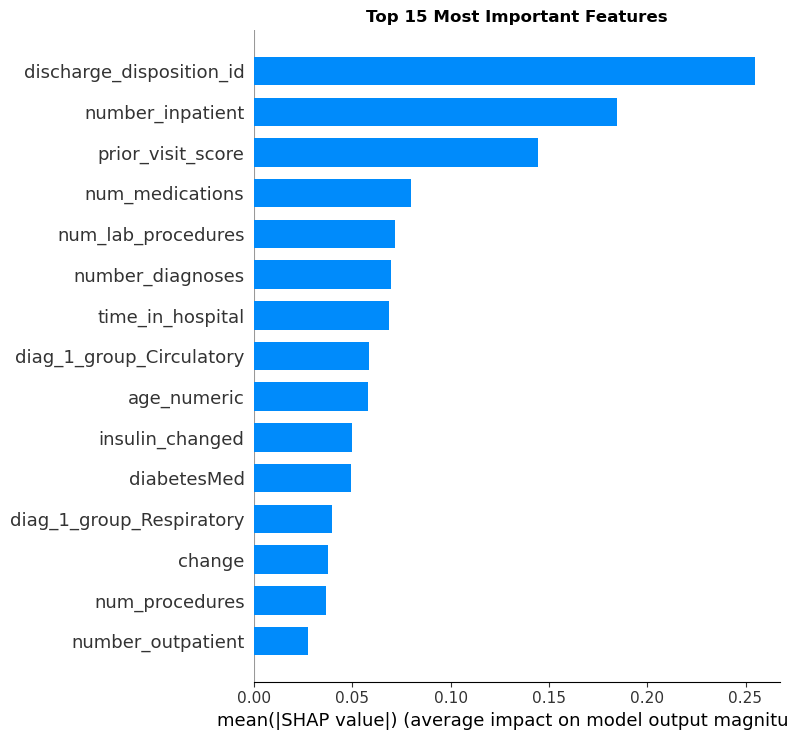

In [23]:
# SHAP Summary Plot 
plt.figure()
shap.summary_plot(shap_values, X_test_sample, 
                  plot_type='bar',
                  max_display=15,
                  show=False)
plt.title('Top 15 Most Important Features', 
          fontweight='bold')
plt.tight_layout()
plt.show()

In [24]:
import joblib
import os

# Create outputs folder
os.makedirs('outputs', exist_ok=True)

# Save the best model
joblib.dump(xgb_model, 'outputs/xgb_model.pkl')
print("Model saved!")

# Save test data for Notebook 4
X_test.to_csv('outputs/X_test.csv', index=False)
y_test.to_csv('outputs/y_test.csv', index=False)
print("Test data saved!")

Model saved!
Test data saved!
